In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

read csv

In [ ]:
df=pd.read_csv('/content/listings.csv')

**Core Question**

---


What factors significantly influence listing revenue in the Asheville short-term rental market?


---






**Data Understanding**


In [ ]:
df.head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,155305,https://www.airbnb.com/rooms/155305,20250922033920,2025-09-22,city scrape,Cottage! BonPaul + Sharky's Hostel,West Asheville Cottage within walking distance...,"We are within easy walk of pubs, breweries, mu...",https://a0.muscache.com/pictures/hosting/Hosti...,746673.0,...,4.75,4.92,4.58,NaN,t,8.0,2.0,3.0,3.0,2.69
1,197263,https://www.airbnb.com/rooms/197263,20250922033920,2025-09-22,city scrape,Tranquil Room & Private Bath,"This is a comfy, peaceful and clean room with ...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,961396.0,...,4.90,4.86,4.97,NaN,f,2.0,1.0,1.0,0.0,0.56
2,209068,https://www.airbnb.com/rooms/209068,20250922033920,2025-09-22,city scrape,Terrace Cottage,Located in one of Asheville's oldest historic ...,Our beautiful Grove Park Historic District clo...,https://a0.muscache.com/pictures/1829924/9f3bf...,1029919.0,...,4.98,4.94,4.80,NaN,f,1.0,1.0,0.0,0.0,0.39


In [ ]:
df.tail(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
2294,1119847569969212837,https://www.airbnb.com/rooms/1119847569969212837,20250922033920,2025-09-22,city scrape,Native penates,Relax with the whole family at this peaceful p...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,490648466.0,...,5.0,5.0,5.0,NaN,f,1.0,1.0,0.0,0.0,0.11
2295,1120308602478756039,https://www.airbnb.com/rooms/1120308602478756039,20250922033920,2025-09-22,previous scrape,Cozy Downtown Apartment,Beautiful centrally located downtown apartment...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,7825587.0,...,NaN,NaN,NaN,NaN,f,2.0,2.0,0.0,0.0,NaN
2296,1120815162638729736,https://www.airbnb.com/rooms/1120815162638729736,20250922033920,2025-09-22,city scrape,Asheville’s Hillside Hideaway,Asheville’s amazing 30 day rental. Welcome to the,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [ ]:
df.shape

(2297, 79)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2297 entries, 0 to 2296
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            2297 non-null   int64  
 1   listing_url                                   2297 non-null   object 
 2   scrape_id                                     2297 non-null   int64  
 3   last_scraped                                  2297 non-null   object 
 4   source                                        2297 non-null   object 
 5   name                                          2297 non-null   object 
 6   description                                   2273 non-null   object 
 7   neighborhood_overview                         1724 non-null   object 
 8   picture_url                                   2296 non-null   object 
 9   host_id                                       2296 non-null   f

In [ ]:
df.shape[0]

2852

In [ ]:
# percentage of nan values
np.round((df.isna().sum()/df.shape[0])*100)

,0
id,0.0
listing_url,0.0
scrape_id,0.0
last_scraped,0.0
source,0.0
name,0.0
description,1.0
neighborhood_overview,25.0
picture_url,0.0
host_id,0.0


In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns',None)

**Determining data types**

---
***convert float to int dtype***

host_listings_count -> int  
host_total_listings_count  
neighbourhood_group_cleansed -> drop   
license -> drop  
calendar_updated -> drop


in a lot of places float dtype is there where int could have been the data type i think that pandas forces float data type when there are null values.

In [ ]:
df[df.select_dtypes(include='float64').columns].isna().sum()

,0
host_listings_count,3
host_total_listings_count,3
neighbourhood_group_cleansed,2852
latitude,0
longitude,0
bathrooms,306
bedrooms,36
beds,316
minimum_minimum_nights,5
maximum_minimum_nights,5


In [ ]:
df.select_dtypes(include='float64').columns

Index(['host_listings_count', 'host_total_listings_count',
       'neighbourhood_group_cleansed', 'latitude', 'longitude', 'bathrooms',
       'bedrooms', 'beds', 'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'license',
       'reviews_per_month'],
      dtype='object')

In [ ]:
df.select_dtypes(include='object').columns

Index(['listing_url', 'last_scraped', 'source', 'name', 'description',
       'neighborhood_overview', 'picture_url', 'host_url', 'host_name',
       'host_since', 'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood', 'property_type', 'room_type', 'bathrooms_text',
       'amenities', 'price', 'has_availability', 'calendar_last_scraped',
       'first_review', 'last_review', 'instant_bookable'],
      dtype='object')

In [ ]:
df.select_dtypes(include='int64').columns

Index(['id', 'scrape_id', 'host_id', 'neighbourhood_cleansed', 'accommodates',
       'minimum_nights', 'maximum_nights', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_private_rooms',
       'calculated_host_listings_count_shared_rooms'],
      dtype='object')

**Dropping columns**

In [ ]:
# dropping empty columns
df.drop(columns=['neighbourhood_group_cleansed', 'calendar_updated', 'license'],axis=1,inplace=True)

In [ ]:
# dropping descriptive columns
df.drop(columns=['description', 'host_about', 'neighborhood_overview'],axis=1,inplace=True)

In [ ]:
# dropping url and related columns as they don't contribute to statistics or modelling
df.drop(columns=['listing_url', 'scrape_id', 'last_scraped', 'picture_url', 'host_url', 'host_thumbnail_url', 'host_picture_url','source'],axis=1,inplace=True)

In [ ]:
# dropping  column neighbourhood as no meaningfull data present in it
df.drop(columns='neighbourhood',axis=1,inplace=True)

In [ ]:
#repitive information with bathroom column
df.drop(columns='bathrooms_text',axis=1,inplace=True)

**Converting values from true/false to 0/1**

In [ ]:
col_list=['host_is_superhost','host_has_profile_pic','host_identity_verified','has_availability','instant_bookable']

In [ ]:
for i in col_list:
  df[i]= np.where(df[i]=='t',1,0)

In [ ]:
# change data type to int from object
df[col_list]=df[col_list].astype('int64')

**Keeping rows with only Asheville, NC as the host location**

In [ ]:
df['host_location'].value_counts()

,count
host_location,
"Asheville, NC",1835
United States,48
"Arden, NC",42
"Candler, NC",29
"Charlotte, NC",25
"Woodfin, NC",24
"Fletcher, NC",20
"North Carolina, United States",18
"Savannah, GA",17


In [ ]:
df=df[df['host_location'].fillna('').str.contains('Asheville, NC')]

In [ ]:
# dropping location column as all have same location
df.drop(columns='host_location',axis=1,inplace=True)

**Removing [' % ', ' $ ', ' , '] from columns**

In [ ]:
# removing % sign
cols = ['host_response_rate','host_acceptance_rate']
for i in cols:
  df[i] = df[i].str.replace('%','')

In [ ]:
# stripping '$' and ',' from price column and convert to float64
df['price']=df['price'].str.strip('$').str.replace(',','').astype('float64')

**Creating a listing_years column and then dropping unnecessary columns**

In [ ]:
# converting dtype to datetime
df['host_since']=pd.to_datetime(df['host_since'])

In [ ]:
# converting dtype to datetime
df['calendar_last_scraped']=pd.to_datetime(df['calendar_last_scraped'])

In [ ]:
# creating listing years columns
df['listing_years']=(df['calendar_last_scraped']-df['host_since']).dt.days//365

In [ ]:
# dropping columns
df.drop(columns=['host_since','calendar_last_scraped'],axis=1,inplace=True)

**creating days_since_last_review column and then dropping the first and last review column**

In [ ]:
df['last_review'] = pd.to_datetime(df['last_review'])

In [ ]:
df['days_since_last_review']=(pd.to_datetime('22 September, 2025')-df['last_review']).dt.days

In [ ]:
df.drop(columns=['first_review','last_review'],axis=1,inplace=True)

**Cleaning property_type columns**

In [ ]:
import re

def clean_property_type(x):
    x = x.lower()
    x = re.sub(r'entire\s+', '', x)
    x = re.sub(r'private room in\s+', '', x)
    x = re.sub(r'private room\s+', '', x)
    x = re.sub(r'shared room in\s+', '', x)
    x = re.sub(r'shared room\s+', '', x)
    x = re.sub(r'room in\s+', '', x)
    return x.strip()

df['property_structure'] = df['property_type'].apply(clean_property_type)

In [ ]:
replacements={'bed and breakfast':'room','home/apt':'home','private room':'room','place':'home','tiny home':'home'}
df['property_structure']=df['property_structure'].replace(replacements)

In [ ]:
cnt=df['property_structure'].value_counts()
idx=cnt[cnt<20].index
df['property_structure']=df['property_structure'].replace(idx,'Other')

In [ ]:
df['property_structure'].value_counts()

,count
property_structure,
home,648
guest suite,240
rental unit,220
condo,115
Other,84
cabin,64
guesthouse,60
cottage,38
townhouse,36


In [ ]:
df['property_type']=df['property_structure']

In [ ]:
df.drop(columns='property_structure',axis=1,inplace=True)

In [ ]:
df.sample(5)

,id,name,host_id,host_name,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,listing_years,days_since_last_review
655,31519951,Asheville Forest Hideaway| 3BR | 15mins to Dow...,33151095.0,Tiffanie,within an hour,100,99,1,NaN,5.0,10.0,"['email', 'phone']",1,1,28803.0,35.514860,-82.478650,cabin,Entire home/apt,7.0,2.0,3.0,4.0,"[""Pack \u2019n play/Travel crib - available up...",180.0,1.0,28.0,1.0,3.0,1125.0,1125.0,2.2,1125.0,1,18.0,45.0,71.0,248.0,75.0,8.0,0.0,82.0,8.0,48.0,8640.0,4.83,4.84,4.92,4.91,4.85,4.88,4.75,1,5.0,5.0,0.0,0.0,0.93,10,57.0
681,32734094,Cabin 2.2 miles from downtown Asheville,56257899.0,Grant,within an hour,100,100,1,NaN,2.0,2.0,"['email', 'phone']",1,0,28804.0,35.624810,-82.531050,cabin,Entire home/apt,8.0,2.0,3.0,3.0,"[""Outdoor dining area"", ""Ceiling fan"", ""Toaste...",196.0,2.0,30.0,2.0,3.0,30.0,30.0,2.5,30.0,1,9.0,22.0,38.0,301.0,80.0,2.0,0.0,43.0,18.0,12.0,2352.0,4.95,4.95,4.94,4.91,4.99,4.93,4.94,1,2.0,2.0,0.0,0.0,1.01,9,93.0
1128,47461928,Cozy Mountain Retreat near Downtown Asheville!,96187307.0,Yonder,within an hour,99,97,1,South Slope Brewing District,223.0,234.0,"['email', 'phone']",1,1,28803.0,35.527481,-82.479295,home,Entire home/apt,9.0,3.0,4.0,5.0,"[""Coffee maker"", ""Ceiling fan"", ""Toaster"", ""Wi...",189.0,1.0,365.0,2.0,4.0,365.0,365.0,2.1,365.0,1,19.0,46.0,70.0,345.0,29.0,4.0,0.0,81.0,7.0,24.0,4536.0,4.90,4.90,4.86,5.00,4.93,4.93,4.76,1,52.0,52.0,0.0,0.0,0.53,9,170.0
665,31742907,The Hilltop Hideaway,71812166.0,Heidi & Ricky,within an hour,100,100,1,NaN,9.0,11.0,"['phone', 'work_email']",1,1,28806.0,35.530920,-82.619550,home,Entire home/apt,6.0,2.5,3.0,3.0,"[""Coffee maker"", ""Wifi"", ""Dishwasher"", ""Fire e...",205.0,3.0,1125.0,3.0,3.0,1125.0,1125.0,3.0,1125.0,1,27.0,57.0,87.0,362.0,73.0,0.0,0.0,98.0,0.0,0.0,0.0,4.92,4.90,4.90,4.99,4.97,4.84,4.82,0,7.0,7.0,0.0,0.0,0.94,9,1141.0
2221,1073995697146084846,Asheville Charm 2 bedroom 2 bath,64331718.0,Melody,within a few hours,100,74,0,Enka,8.0,8.0,"['email', 'phone']",1,0,28715.0,35.548560,-82.651080,rental unit,Entire home/apt,4.0,2.0,2.0,2.0,"[""Stainless steel single oven"", ""Electric stov...",113.0,3.0,365.0,3.0,3.0,365.0,365.0,3.0,365.0,1,29.0,59.0,89.0,269.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,6.0,6.0,0.0,0.0,NaN,9,NaN


**Creating columns from the amenities column including amenities_count, and columns for useful amenities**

In [ ]:
import ast
df['amenities_count']=df['amenities'].apply(lambda x:len(ast.literal_eval(x)))

In [ ]:
import ast

def normalize_amenities(x):
    # Convert string list to actual list
    amenities_list = ast.literal_eval(x)
    # Lowercase and strip
    amenities_list = [a.lower().strip() for a in amenities_list]
    return amenities_list

df['amenities_normalized'] = df['amenities'].apply(normalize_amenities)

In [ ]:
# Define mapping
chosen_amenities_keywords = {
    'amenity_kitchen': ['kitchen'],
    'amenity_microwave': ['microwave','oven','stove'],
    'amenity_refrigerator': ['refrigerator','mini fridge'],
    'amenity_ac': ['air conditioning','air conditioner','ac'],
    'amenity_pets': ['pet'],
    'amenity_parking': ['parking'],
    'amenity_wifi': ['wifi']
}

for col, keywords in chosen_amenities_keywords.items():
    df[col] = df['amenities_normalized'].apply(
        lambda x: int(any(any(kw in a for kw in keywords) for a in x))
    )

**Dropping amenities normalized and amenities column**

In [ ]:
df.drop(columns=['amenities_normalized','amenities'],axis=1,inplace=True)

**Dropping host name host id name and listing id**

In [ ]:
df.drop(columns=['id','name','host_id','host_name'],axis=1,inplace=True)

**Saving dataset to drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.to_csv('/content/drive/MyDrive/airbnb/listings.csv', index=False)

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/airbnb/listings.csv')

**Making columns for email phone and work email verifications and then dropping the host_verification column**

In [ ]:
df['host_verification_normalized'] = df['host_verifications'].apply(ast.literal_eval)

In [ ]:
import ast
verifications = {
    'has_email_verified':'email',
    'has_phone_verified' : 'phone',
    'has_work_email':'work_email'
}
for col,keyword in verifications.items():
 df[col]= df['host_verification_normalized'].apply(lambda x: int(any(keyword in a for a in x)))

In [ ]:
df.drop(columns=['host_verifications','host_verification_normalized'],axis=1,inplace=True)

In [ ]:
df.sample(5)

,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,listing_years,days_since_last_review,amenities_count,amenity_kitchen,amenity_microwave,amenity_refrigerator,amenity_ac,amenity_pets,amenity_parking,amenity_wifi,has_email_verified,has_phone_verified,has_work_email
499,within a day,100.0,75.0,0,NaN,1.0,1.0,1,1,28805.0,35.62087,-82.50444,guest suite,Entire home/apt,2.0,1.0,1.0,1.0,95.0,2.0,14.0,2.0,2.0,14.0,14.0,2.0,14.0,1,3.0,25.0,41.0,41.0,76.0,5.0,0.0,41.0,9.0,30.0,2850.0,5.00,5.00,4.99,5.00,5.00,5.00,4.99,0,1.0,1.0,0.0,0.0,0.92,9,91.0,28,1,1,1,1,0,1,1,1,1,0
634,within a few hours,100.0,93.0,0,NaN,2.0,3.0,1,1,28801.0,35.60773,-82.55197,condo,Entire home/apt,2.0,1.0,1.0,1.0,113.0,10.0,1125.0,10.0,10.0,1125.0,1125.0,10.0,1125.0,1,0.0,25.0,55.0,330.0,20.0,0.0,0.0,66.0,0.0,0.0,0.0,4.95,4.85,4.65,4.95,5.00,5.00,4.90,0,1.0,1.0,0.0,0.0,0.27,13,635.0,29,1,1,1,1,0,1,1,1,1,0
985,within an hour,100.0,100.0,1,Montford Area Historic District,1.0,1.0,1,1,28801.0,35.60230,-82.56036,guesthouse,Entire home/apt,2.0,1.0,1.0,1.0,87.0,1.0,30.0,1.0,1.0,1125.0,1125.0,1.0,1125.0,1,8.0,38.0,65.0,336.0,328.0,62.0,3.0,76.0,56.0,255.0,22185.0,4.91,4.94,4.90,4.96,4.95,4.97,4.84,1,1.0,1.0,0.0,0.0,6.30,12,17.0,34,0,1,1,1,0,1,1,1,1,1
40,within an hour,100.0,100.0,1,NaN,4.0,6.0,1,1,28801.0,35.59541,-82.55329,loft,Entire home/apt,4.0,1.0,1.0,2.0,150.0,1.0,89.0,1.0,1.0,1125.0,1125.0,1.0,1125.0,1,6.0,19.0,46.0,306.0,931.0,76.0,10.0,50.0,93.0,255.0,38250.0,4.97,4.98,4.98,4.99,5.00,4.94,4.85,0,2.0,2.0,0.0,0.0,6.59,13,4.0,54,1,1,1,1,1,1,1,1,1,0
176,within an hour,100.0,55.0,1,NaN,2.0,3.0,1,1,28806.0,35.58087,-82.59534,bungalow,Private room,2.0,1.0,1.0,1.0,51.0,2.0,60.0,1.0,2.0,60.0,60.0,1.4,60.0,1,21.0,46.0,76.0,351.0,196.0,12.0,2.0,87.0,9.0,72.0,3672.0,4.86,4.89,4.72,4.96,4.98,4.95,4.83,0,2.0,0.0,2.0,0.0,1.78,10,9.0,34,1,1,1,1,0,1,1,1,1,0


In [ ]:
# scoring=((df.isna().sum()/df.shape[0])*100).sort_values(ascending=False)
# scoring[scoring>0].index
((df.isna().sum()/df.shape[0])*100).sort_values(ascending=False)

,0
host_response_time,0.0
host_response_rate,0.0
host_acceptance_rate,0.0
host_is_superhost,0.0
host_listings_count,0.0
host_total_listings_count,0.0
host_has_profile_pic,0.0
host_identity_verified,0.0
neighbourhood_cleansed,0.0
latitude,0.0


**Dropping columns and rows depending on percentage of missing values**

In [ ]:
df.drop(columns='host_neighbourhood',axis=1,inplace=True)

In [ ]:
# price is one of the target variables cant have null values in it
df.dropna(subset=['price'],inplace=True)

In [ ]:
df['reviews_per_month']=df['reviews_per_month'].fillna(0)

In [ ]:
columns=['review_scores_location', 'review_scores_value',
       'review_scores_checkin', 'review_scores_accuracy',
       'review_scores_rating', 'days_since_last_review',
       'review_scores_cleanliness', 'review_scores_communication',
       'maximum_maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights']
for i in columns:
  df[i] = df[i].fillna(0)

In [ ]:
df[df['host_response_time'].isna()][['host_response_time','host_response_rate', 'host_acceptance_rate','listing_years','number_of_reviews','reviews_per_month']]

,host_response_time,host_response_rate,host_acceptance_rate,listing_years,number_of_reviews,reviews_per_month
2,NaN,NaN,50.0,14,67.0,0.39
5,NaN,NaN,NaN,13,47.0,0.30
11,NaN,NaN,100.0,12,14.0,0.10
14,NaN,NaN,NaN,12,125.0,0.82
19,NaN,NaN,NaN,12,173.0,1.14
30,NaN,NaN,100.0,12,5.0,0.04
32,NaN,NaN,80.0,14,59.0,0.43
55,NaN,NaN,NaN,11,300.0,2.26
65,NaN,NaN,0.0,10,44.0,0.41
73,NaN,NaN,NaN,10,157.0,1.24


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/airbnb/listings.csv')

**Filling missing values**

In [ ]:
#filled na values with missing
df['host_response_time']=df['host_response_time'].fillna('missing')

In [ ]:
#making missing indicator columns and then filling the na values with median
df['host_response_rate_missing'] = df['host_response_rate'].isna().astype(int)
df['host_acceptance_rate_missing'] = df['host_acceptance_rate'].isna().astype(int)

df['host_response_rate'] = df['host_response_rate'].fillna(df['host_response_rate'].median())
df['host_acceptance_rate'] = df['host_acceptance_rate'].fillna(df['host_acceptance_rate'].median())

**Checking skewness of data**

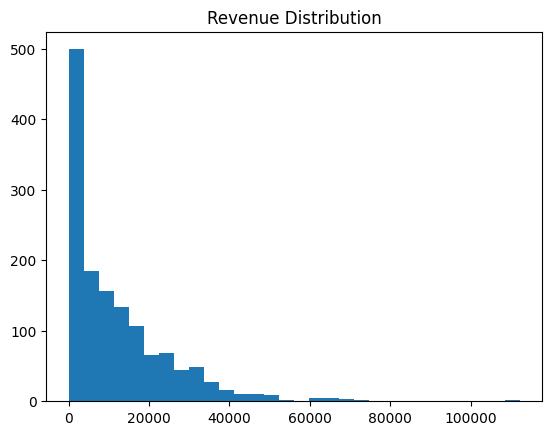

In [ ]:
plt.hist(df['estimated_revenue_l365d'],bins=30)
plt.title("Revenue Distribution")
plt.show()

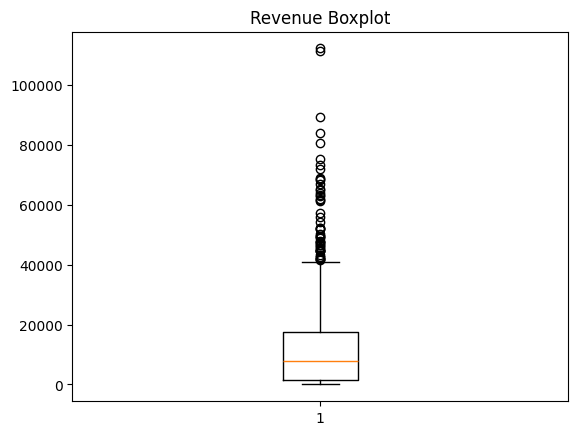

In [ ]:
plt.boxplot(df['estimated_revenue_l365d'])
plt.title('Revenue Boxplot')
plt.show()

In [ ]:
df['estimated_revenue_l365d'].skew()

np.float64(2.1295367085768815)

In [ ]:
import scipy
from scipy.stats import shapiro
shapiro(df['estimated_revenue_l365d'])

ShapiroResult(statistic=np.float64(0.797346126485435), pvalue=np.float64(1.2770313902746021e-38))

In [ ]:
df['log_revenue']=np.log1p(df['estimated_revenue_l365d'])

In [ ]:
df['log_revenue'].skew()

np.float64(-1.5796996483967063)

In [ ]:
df.shape[0]

1400

In [ ]:
(df['estimated_revenue_l365d'] == 0).mean()

np.float64(0.14857142857142858)

In [ ]:
df['estimated_revenue_l365d'].describe()

,estimated_revenue_l365d
count,1400.000000
mean,12011.677857
std,13751.206072
min,0.000000
25%,1608.000000
50%,7872.000000
75%,17538.750000
max,112200.000000


In [ ]:
df.columns

Index(['host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_listings_count', 'host_total_listings_count',
       'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 

**Statistical Testing**





**Do superhosts earn more revenue than non-superhosts?**

Null hypothesis (H₀): There is no difference in mean revenue between superhosts and non-superhosts.

Alternative hypothesis (H₁): There is a difference in mean revenue between superhosts and non-superhosts.

In [ ]:
df.groupby(by='host_is_superhost')[['estimated_revenue_l365d','log_revenue']].mean()

,estimated_revenue_l365d,log_revenue
host_is_superhost,,
0,4404.994911,5.152062
1,14980.323734,8.661366


In [ ]:
from scipy.stats import ttest_ind
group_0 = df[df['host_is_superhost']==0]['log_revenue']
group_1 = df[df['host_is_superhost']==1]['log_revenue']

ttest_ind(group_1,group_0,equal_var=False)
# Reject H₀ → superhosts earn significantly more revenue

TtestResult(statistic=np.float64(15.968734977821333), pvalue=np.float64(8.637787273540908e-47), df=np.float64(506.54304874585256))

<Axes: xlabel='host_is_superhost', ylabel='log_revenue'>

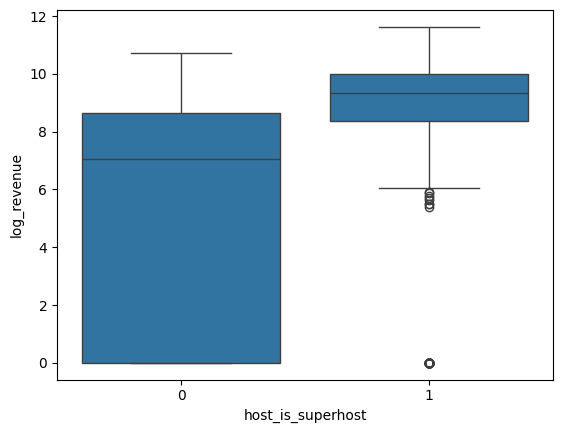

In [ ]:
sns.boxplot(x='host_is_superhost', y='log_revenue', data=df)

ttest host identity verified

In [ ]:
group_0 = df[df['host_identity_verified']==0]['log_revenue']
group_1 = df[df['host_identity_verified']==1]['log_revenue']

ttest_ind(group_1,group_0,equal_var=False)
# verified hosts earn more
# null hypothesis rejected that both earn the same


TtestResult(statistic=np.float64(2.1417466156223894), pvalue=np.float64(0.03339631133075784), df=np.float64(204.54840980069505))

<Axes: xlabel='host_identity_verified', ylabel='log_revenue'>

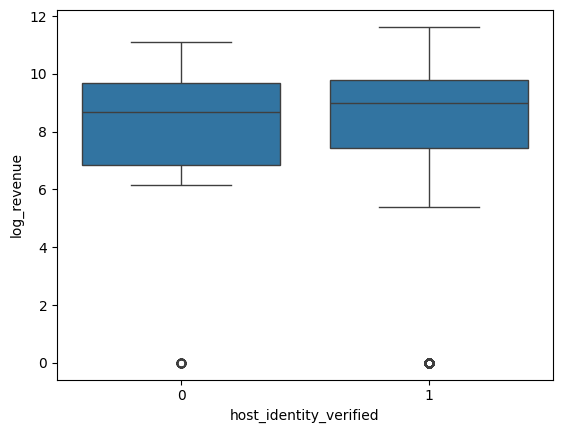

In [ ]:
sns.boxplot(x='host_identity_verified', y='log_revenue', data=df)

ttest instant bookable

In [ ]:
group_0 = df[df['instant_bookable']==0]['log_revenue']
group_1 = df[df['instant_bookable']==1]['log_revenue']

ttest_ind(group_1,group_0,equal_var=False)
# reject null hypothesis as p value is large than 0.05 and there is a difference in means of two groups
# instant bookables earn more

TtestResult(statistic=np.float64(1.606715201465989), pvalue=np.float64(0.10842086195028042), df=np.float64(1038.440446125954))

<Axes: xlabel='instant_bookable', ylabel='log_revenue'>

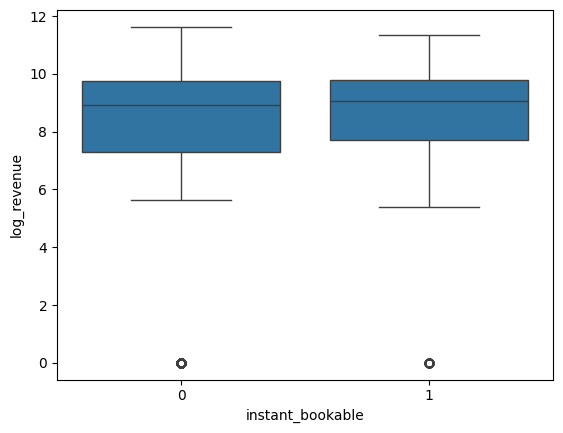

In [ ]:
sns.boxplot(x='instant_bookable', y='log_revenue', data=df)

ttest amenity_wifi

In [ ]:
group_0 = df[df['amenity_wifi']==0]['log_revenue']
group_1 = df[df['amenity_wifi']==1]['log_revenue']

ttest_ind(group_1,group_0,equal_var=False)
# fail to reject null hypothesis so having wifi or not doesnt really affects

TtestResult(statistic=np.float64(0.9344235091605436), pvalue=np.float64(0.4028317704945577), df=np.float64(4.012484798250196))

In [ ]:
group_0 = df[df['has_email_verified']==0]['log_revenue']
group_1 = df[df['has_email_verified']==1]['log_revenue']

ttest_ind(group_1,group_0,equal_var=False)
# reject null hypothesis having email verified leads to more earning

TtestResult(statistic=np.float64(1.3350854715699363), pvalue=np.float64(0.19066850411850414), df=np.float64(34.19719748061745))

In [ ]:
group_0 = df[df['has_work_email']==0]['log_revenue']
group_1 = df[df['has_work_email']==1]['log_revenue']

ttest_ind(group_1,group_0,equal_var=False)
# fail to reject null hypothesis having work email doesnt really affects earnings

TtestResult(statistic=np.float64(0.30364819206726834), pvalue=np.float64(0.7615400378577905), df=np.float64(438.24550617419004))

In [ ]:
group_0 = df[df['amenity_parking']==0]['log_revenue']
group_1 = df[df['amenity_parking']==1]['log_revenue']

ttest_ind(group_1,group_0,equal_var=False)
# fail to reject null hypothesis. having parking doesnt really affects earnings

TtestResult(statistic=np.float64(0.6623722675376744), pvalue=np.float64(0.5141772375049845), df=np.float64(23.498482995960376))

**ANOVA**

anova room_type

In [ ]:
from scipy.stats import f_oneway

# Create groups
group1 = df[df['room_type'] == 'Entire home/apt']['log_revenue']
group2 = df[df['room_type'] == 'Private room']['log_revenue']
group3 = df[df['room_type'] == 'Shared room']['log_revenue']
group4 = df[df['room_type'] == 'Hotel room']['log_revenue']


# Perform ANOVA
f_stat, p_val = f_oneway(group1, group2, group3,group4)
print(f"F-statistic: {f_stat}, p-value: {p_val}")
#reject null hypothesis as p <0.05
# Atleast one group mean is different

F-statistic: 12.800026681605448, p-value: 2.9749658716094576e-08


In [ ]:
df.groupby(by='room_type')['log_revenue'].mean().sort_values(ascending=False)

,log_revenue
room_type,
Entire home/apt,7.863709
Shared room,7.733977
Hotel room,7.249005
Private room,6.028794


<Axes: xlabel='room_type', ylabel='log_revenue'>

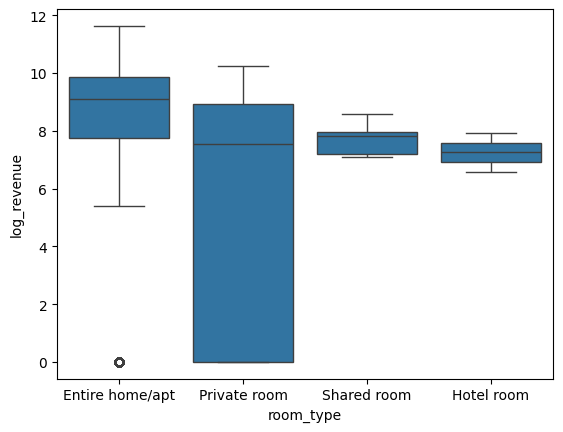

In [ ]:
import seaborn as sns
sns.boxplot(x='room_type', y='log_revenue', data=df)

ANOVA host_response_time

In [ ]:
# Create groups
group1 = df[df['host_response_time'] == 'within an hour']['log_revenue']
group2 = df[df['host_response_time'] == 'within a few hours']['log_revenue']
group3 = df[df['host_response_time'] == 'within a day']['log_revenue']
group4 = df[df['host_response_time'] == 'a few days or more']['log_revenue']
group5 = df[df['host_response_time'] == 'missing']['log_revenue']


# Perform ANOVA
f_stat, p_val = f_oneway(group1, group2, group3,group4,group5)
print(f"F-statistic: {f_stat}, p-value: {p_val}")
#reject null hypothesis as p <0.05
# Atleast one group mean is different

F-statistic: 82.46400605423777, p-value: 6.819563220225305e-63


In [ ]:
df.groupby(by='host_response_time')['log_revenue'].mean().sort_values(ascending=False)

,log_revenue
host_response_time,
within an hour,8.339339
within a few hours,6.212092
within a day,4.583805
missing,3.922069
a few days or more,2.660597


In [ ]:
df.groupby(by='host_response_time')['estimated_revenue_l365d'].median().sort_values(ascending=False)

,estimated_revenue_l365d
host_response_time,
within an hour,9672.0
within a few hours,2478.0
within a day,678.0
a few days or more,0.0
missing,0.0


ANOVA property_type

In [ ]:
# Create groups
group1 = df[df['property_type'] == 'home']['log_revenue']
group2 = df[df['property_type'] == 'guest suite']['log_revenue']
group3 = df[df['property_type'] == 'rental unit']['log_revenue']
group4 = df[df['property_type'] == 'condo']['log_revenue']
group5 = df[df['property_type'] == 'Other']['log_revenue']


# Perform ANOVA
f_stat, p_val = f_oneway(group1, group2, group3,group4,group5)
print(f"F-statistic: {f_stat}, p-value: {p_val}")
#reject null hypothesis as p <0.05
# Atleast one group mean is different

F-statistic: 4.098078216092867, p-value: 0.002653293451420753


In [ ]:
df.groupby(by='property_type')['estimated_revenue_l365d'].median().sort_values(ascending=False)

,estimated_revenue_l365d
property_type,
loft,18060.0
cottage,12180.0
guesthouse,11097.0
condo,10692.0
cabin,9600.0
guest suite,8316.0
townhouse,7860.0
home,7297.0
bungalow,7020.0


In [ ]:
df['property_type'].value_counts()

,count
property_type,
home,566
guest suite,211
rental unit,190
condo,111
Other,73
cabin,57
guesthouse,52
cottage,36
townhouse,31


In [ ]:
numeric_columns=df.select_dtypes(include=np.number)
numeric_columns.corr()

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,listing_years,days_since_last_review,amenities_count,amenity_kitchen,amenity_microwave,amenity_refrigerator,amenity_ac,amenity_pets,amenity_parking,amenity_wifi,has_email_verified,has_phone_verified,has_work_email,host_response_rate_missing,host_acceptance_rate_missing,log_revenue
host_response_rate,1.000000,0.275747,0.171028,0.045651,0.046237,-0.007691,0.024619,0.030192,-0.007585,0.031020,0.022952,-0.009554,-0.015227,0.003426,-0.058708,-0.085399,0.009013,-0.136233,-0.072716,0.030164,0.036427,-0.095505,0.034262,0.014365,-0.049538,-0.045817,-0.048860,-0.043113,0.083157,0.085614,0.077027,-0.052805,0.095551,0.099738,0.085140,0.179954,0.178131,0.183195,0.179544,0.182626,0.177077,0.174296,0.067296,0.051960,0.052893,-0.019090,0.011558,0.101674,0.012975,-0.041602,0.056219,-0.009987,0.090593,0.067594,-0.007691,0.014350,0.042088,0.004424,0.103536,NaN,0.062088,0.044593,-0.132020,0.148693
host_acceptance_rate,0.275747,1.000000,0.295752,0.135112,0.136143,-0.020333,0.054837,0.051938,0.017744,-0.012703,0.110511,0.095846,0.065889,0.072880,0.108591,-0.118073,0.054966,-0.141846,-0.095225,0.116288,0.131324,-0.126622,0.126464,0.253312,-0.054342,-0.016231,-0.003316,0.032546,0.165472,0.202463,0.173444,-0.000706,0.203901,0.219951,0.212235,0.189063,0.183457,0.190702,0.181685,0.183647,0.184192,0.175969,0.166666,0.142020,0.143358,-0.036744,0.005648,0.212033,-0.083142,-0.225671,0.109540,0.015680,0.150441,0.159559,0.102408,0.034182,-0.005301,0.019014,0.073810,NaN,0.060550,-0.095098,0.081751,0.342917
host_is_superhost,0.171028,0.295752,1.000000,0.256301,0.254551,0.026122,0.074357,0.089766,0.026736,-0.008488,0.137390,0.119038,0.073412,0.069979,-0.023283,-0.100932,-0.036907,-0.130627,-0.055006,0.002444,0.012800,-0.085025,0.009676,0.105018,-0.033127,-0.002469,0.023999,0.115779,0.241634,0.329376,0.262953,0.031132,0.351180,0.380322,0.345694,0.198683,0.193330,0.202922,0.189097,0.192091,0.182901,0.186226,0.090454,0.248353,0.252040,-0.122828,0.050250,0.334105,-0.080539,-0.340566,0.168603,0.101059,0.196887,0.163053,0.085685,0.021460,-0.009027,0.042540,0.087318,NaN,0.114887,-0.440641,-0.394073,0.465685
host_listings_count,0.045651,0.135112,0.256301,1.000000,0.984530,0.022762,0.147072,-0.036129,0.004185,0.110345,0.285493,0.415277,0.285569,0.265846,0.221681,-0.071650,0.087997,-0.011157,0.003171,-0.306245,-0.313219,-0.019313,-0.312511,0.028312,0.110500,0.133353,0.122127,0.254900,-0.225796,-0.170918,-0.180333,0.133749,-0.179871,-0.193499,-0.021447,0.029885,0.039431,0.049700,0.030477,0.032067,0.039532,-0.007592,0.170579,0.800575,0.801739,-0.083990,-0.025490,-0.232611,-0.122824,-0.044053,-0.081589,0.160633,0.112853,0.071711,0.022509,0.064747,-0.010102,0.025571,0.067789,NaN,0.250086,-0.131612,-0.105441,0.043802
host_total_listings_count,0.046237,0.136143,0.254551,0.984530,1.000000,0.023218,0.149117,-0.038400,-0.010597,0.117747,0.284027,0.410721,0.289939,0.263487,0.210782,-0.070530,0.126233,-0.001027,0.009143,-0.323316,-0.328214,-0.011045,-0.328483,0.028457,0.093003,0.123731,0.114517,0.244775,-

In [ ]:
numeric_columns.columns

Index(['host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_listings_count', 'host_total_listings_count',
       'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights',
       'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'number_of_reviews', 'number_of_reviews_ltm',
       'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly',
       'estimated_occupancy_l365d', 'estimated_revenue_l365d',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_locati

In [ ]:
cols = ['log_revenue', 'price', 'accommodates', 'bedrooms', 'beds',
        'number_of_reviews', 'reviews_per_month', 'listing_years',
        'estimated_occupancy_l365d', 'calculated_host_listings_count_entire_homes']

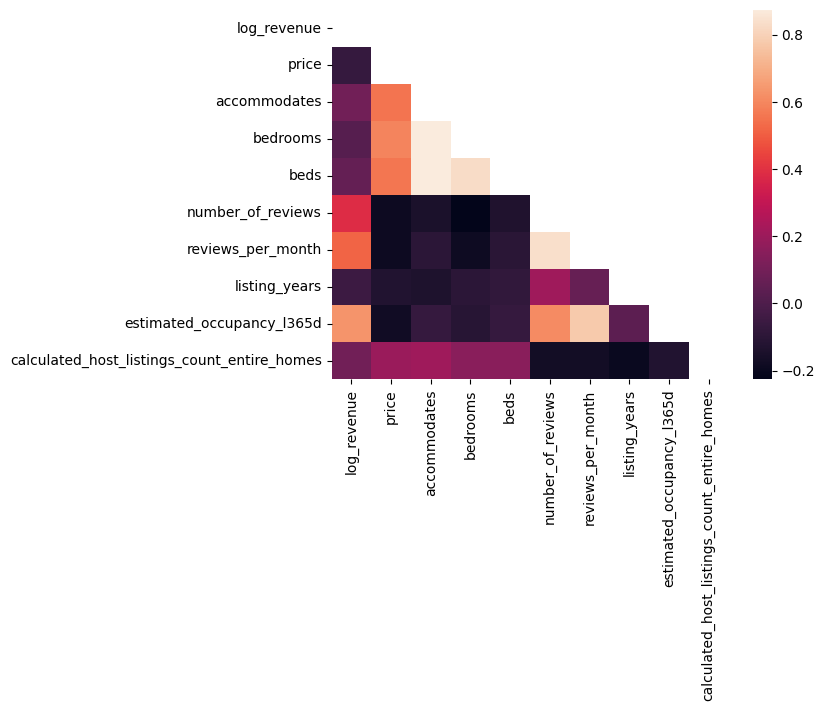

In [ ]:
corr= df[cols].corr()
mask = np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(data=corr,mask=mask)
plt.show()